# Inference Notebook — AG News DistilBERT

This notebook loads the fine-tuned DistilBERT model from Hugging Face Hub and performs inference on sample data.

**Model**: [`Recurrent/ag-news-distilbert`](https://huggingface.co/Recurrent/ag-news-distilbert)  
**Task**: 4-class text classification (World, Sports, Business, Sci/Tech)

## Step 1: Install Dependencies

In [ ]:
!pip install -q transformers torch pandas datasets

## Step 2: Load Model and Tokenizer from Hugging Face Hub

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch
import pandas as pd

# Model repository on Hugging Face
HF_REPO_ID = "Recurrent/ag-news-distilbert"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(HF_REPO_ID)
model = AutoModelForSequenceClassification.from_pretrained(HF_REPO_ID)

print(f"Model loaded from: https://huggingface.co/{HF_REPO_ID}")
print(f"Number of labels: {model.config.num_labels}")
print(f"Labels: {model.config.id2label}")

config.json:   0%|          | 0.00/853 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded from: https://huggingface.co/Recurrent/ag-news-distilbert
Number of labels: 4
Labels: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


## Step 3: Create Inference Pipeline

In [3]:
# Create a text classification pipeline
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    top_k=None  # Return scores for all classes
)

print("Inference pipeline ready!")

Inference pipeline ready!


## Step 4: Load Sample Test Data

In [4]:
import json, requests
from datasets import load_dataset

# Load test data from Hugging Face Hub
HF_DATASET_REPO = "Recurrent/prepared_data_mlops2"
dataset = load_dataset(HF_DATASET_REPO, data_dir="prepared_data")
test_df = dataset["test"].to_pandas()

# Load id2label from GitHub
id2label_url = "https://raw.githubusercontent.com/riteshmaury-iitj/group13-assignment-mlops/ritesh_dev/id2label.json"
id2label = {int(k): v for k, v in requests.get(id2label_url).json().items()}

# Take a sample of 3 examples per class
sample_df = test_df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(n=min(3, len(x)), random_state=42)
).reset_index(drop=True)

print(f"Total test samples: {len(test_df)}")
print(f"Selected sample size: {len(sample_df)}")
print(f"Labels: {id2label}")
sample_df.head(12)

prepared_data/train_prepared.csv:   0%|          | 0.00/27.4M [00:00<?, ?B/s]

test_prepared.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Total test samples: 7600
Selected sample size: 12
Labels: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


/tmp/ipykernel_58/750715779.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = test_df.groupby("label", group_keys=False).apply(


,text,label
0,large explosion heard in central baghdad reute...,0
1,israel oks more west bank settlement homes jer...,0
2,scores of iraqis die in 3 days of attacks us t...,0
3,agassi overcomes verdasco power stockholm reut...,1
4,cycling ulmer 39s scorching times in secret ri...,1
5,guyanese batsmen lead windies into semis of ic...,1
6,ford monthly sales drop company looks to new v...,2
7,united 39s pension dilemma united airlines say...,2
8,comcast part of group wanting to buy mgm a con...,2
9,china closes 1600 internet cafes in crackdown ...,3


## Step 5: Run Inference on Sample Data

In [5]:
# Run inference
texts = sample_df["text"].tolist()
predictions = classifier(texts, truncation=True, max_length=128)

# Extract predicted labels and confidence scores
predicted_labels = []
confidences = []

for pred in predictions:
    # Get the top prediction (highest score)
    top_pred = max(pred, key=lambda x: x["score"])
    predicted_labels.append(top_pred["label"])
    confidences.append(top_pred["score"])

# Build results dataframe
results_df = pd.DataFrame({
    "text": [t[:100] + "..." if len(t) > 100 else t for t in texts],
    "true_label": sample_df["label"].map(id2label).values,
    "predicted_label": predicted_labels,
    "confidence": confidences
})

results_df

,text,true_label,predicted_label,confidence
0,large explosion heard in central baghdad reute...,World,World,0.999505
1,israel oks more west bank settlement homes jer...,World,World,0.999356
2,scores of iraqis die in 3 days of attacks us t...,World,World,0.999622
3,agassi overcomes verdasco power stockholm reut...,Sports,Sports,0.999591
4,cycling ulmer 39s scorching times in secret ri...,Sports,Sports,0.999109
5,guyanese batsmen lead windies into semis of ic...,Sports,Sports,0.999410
6,ford monthly sales drop company looks to new v...,Business,Business,0.999038
7,united 39s pension dilemma united airlines say...,Business,Business,0.999189
8,comcast part of group wanting to buy mgm a con...,Business,Business,0.966596
9,china closes 1600 internet cafes in crackdown ...,Sci/Tech,Sci/Tech,0.983665


## Step 6: Evaluate Inference Accuracy

In [6]:
# Calculate accuracy on sample
correct = (results_df["true_label"] == results_df["predicted_label"]).sum()
total = len(results_df)
accuracy = correct / total

print(f"Sample Inference Results:")
print(f"  Correct: {correct}/{total}")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Average Confidence: {results_df['confidence'].mean():.4f}")

Sample Inference Results:
  Correct: 12/12
  Accuracy: 100.00%
  Average Confidence: 0.9900


### Step 6.1: Confusion Matrix on Full Test Dataset


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Run inference on the full test dataset
print("Running inference on full test dataset... This may take a few minutes.")
all_texts = test_df["text"].tolist()
all_true_labels = test_df["label"].tolist()

# Predict in batches
batch_size = 64
all_predicted_labels = []

for i in range(0, len(all_texts), batch_size):
    batch = all_texts[i:i+batch_size]
    batch_preds = classifier(batch, truncation=True, max_length=128)
    for pred in batch_preds:
        top_pred = max(pred, key=lambda x: x["score"])
        all_predicted_labels.append(top_pred["label"])
    if (i // batch_size) % 10 == 0:
        print(f"  Processed {min(i+batch_size, len(all_texts))}/{len(all_texts)} samples...")

# Map true labels to label names
all_true_label_names = [id2label[l] for l in all_true_labels]

print(f"\nInference complete on {len(all_texts)} samples.")

# Classification Report
label_names = list(id2label.values())
print("\nClassification Report:")
print(classification_report(all_true_label_names, all_predicted_labels, target_names=label_names))

Running inference on full test dataset... This may take a few minutes.
  Processed 64/7600 samples...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 704/7600 samples...
  Processed 1344/7600 samples...
  Processed 1984/7600 samples...
  Processed 2624/7600 samples...
  Processed 3264/7600 samples...
  Processed 3904/7600 samples...
  Processed 4544/7600 samples...
  Processed 5184/7600 samples...
  Processed 5824/7600 samples...
  Processed 6464/7600 samples...
  Processed 7104/7600 samples...

Inference complete on 7600 samples.

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.91      0.91      1900
      Sports       0.91      0.93      0.92      1900
    Business       0.98      0.99      0.99      1900
    Sci/Tech       0.96      0.94      0.95      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



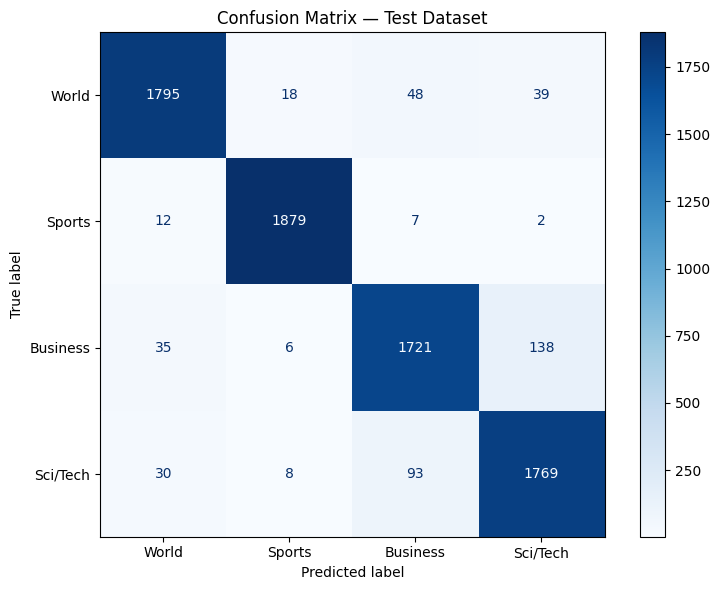

In [8]:
# Confusion Matrix
cm = confusion_matrix(all_true_label_names, all_predicted_labels, labels=label_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — Test Dataset")
plt.tight_layout()
plt.show()

## Step 7: Inference on Custom Text

In [9]:
import re
import string

def clean_text(text):
    """Clean and normalise text (same logic as prepare_data.ipynb)."""
    if pd.isna(text) or text is None:
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove HTML entities and tags
    text = re.sub(r'&lt;.*?&gt;', '', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&quot;', '"', text)
    text = re.sub(r'&#?\w+;', '', text)

    # Remove URLs
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)

    # Remove backslashes
    text = text.replace('\\', ' ')

    # Replace #36; encoding with $
    text = re.sub(r'#36;', '$', text)

    # Strip punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Custom text inputs
custom_texts = [
    "The stock market surged today as investors reacted to positive earnings reports from major tech companies.",
    "NASA successfully launched a new satellite to study climate change patterns in the Arctic region.",
    "Manchester United defeated Liverpool 3-1 in an exciting Premier League match at Old Trafford.",
    "The United Nations Security Council held an emergency meeting to discuss the ongoing conflict in the region."
]

# Apply the same data preparation logic used during training
custom_texts_cleaned = [clean_text(text) for text in custom_texts]

print("Custom Text Inference Results:")
print("=" * 80)

custom_predictions = classifier(custom_texts_cleaned, truncation=True, max_length=128)

for text, cleaned, pred in zip(custom_texts, custom_texts_cleaned, custom_predictions):
    top_pred = max(pred, key=lambda x: x["score"])
    print(f"\nOriginal: {text[:80]}...")
    print(f"Cleaned:  {cleaned[:80]}...")
    print(f"  Predicted: {top_pred['label']} (confidence: {top_pred['score']:.4f})")
    print(f"  All scores: {', '.join(f'{p['label']}: {p['score']:.3f}' for p in sorted(pred, key=lambda x: -x['score']))}")
    

Custom Text Inference Results:

Original: The stock market surged today as investors reacted to positive earnings reports ...
Cleaned:  the stock market surged today as investors reacted to positive earnings reports ...
  Predicted: Business (confidence: 0.6054)
  All scores: Business: 0.605, Sci/Tech: 0.392, World: 0.002, Sports: 0.000

Original: NASA successfully launched a new satellite to study climate change patterns in t...
Cleaned:  nasa successfully launched a new satellite to study climate change patterns in t...
  Predicted: Sci/Tech (confidence: 0.9918)
  All scores: Sci/Tech: 0.992, World: 0.007, Business: 0.001, Sports: 0.000

Original: Manchester United defeated Liverpool 3-1 in an exciting Premier League match at ...
Cleaned:  manchester united defeated liverpool 31 in an exciting premier league match at o...
  Predicted: Sports (confidence: 0.9978)
  All scores: Sports: 0.998, World: 0.002, Business: 0.000, Sci/Tech: 0.000

Original: The United Nations Security Council 